# Exercise 2

Deadline 18.11.2025

Anna Bütfering

Lea Neumann

Juan Provencio

## Two dimensional data with bottleneck

Use pytorch to implement and train an autoencoder. The autoencoder's constructor should have
four arguments:

**input_size**: the data dimension (so that we can later reuse the autoencoder in task 3)

**bottleneck_size**: the code dimension (also for reuse in task 3 in the present task the code dimension is always 1)

**hidden_size**: the dimension of the hidden layers (should be larger than the data dimension!)

**layers**: the number of hidden layers

In [369]:
# Torch
import torch 
from torch import nn, optim
from torch import sqrt, exp
# Sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
# Etc.
import matplotlib.pyplot as plt
from tqdm import tqdm
## Plot options
from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB',
                                                '#E55934', '#FA7921',
                                                '#8D230F', '#1B998B'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'
# Define textbox style for plots
textbox_style = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')

In [168]:
# Dataset from two moons:
X, y = make_moons(n_samples=125000, noise=0.1, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
#y = torch.tensor(y, dtype=torch.long)

# Split into train and test sets:
X_test, X_train = train_test_split(X, test_size=0.2, random_state=42)

In [274]:
class Autoencoder(nn.Module):
    def __init__(self, input_size, bottleneck_size, hidden_size, layers):
        # Initialize AE with required parameters
        self.input_size = input_size
        self.bottleneck_size = bottleneck_size
        self.hidden_size = hidden_size
        self.layers = layers
        # Save hyperparameters
        self.lr = 0.001
        # Save results
        self.train_losses = []
        self.test_losses = []
        self.outputs = []

        # Structure: [ENCODER -> {BOTTLENECK] -> DECODER}

        # First call super constructor
        super(Autoencoder, self).__init__()

        # Encoder
        ## Initial layer input -> hidden
        self.encoder = nn.ModuleList()
        self.encoder.append(nn.Linear(input_size, hidden_size))
        self.encoder.append(nn.ReLU())
        ## Hidden layers hidden -> hidden
        for _ in range(layers - 1):
            self.encoder.append(nn.Linear(hidden_size, hidden_size))
            self.encoder.append(nn.ReLU())
        ## Final layer hidden -> bottleneck
        self.encoder.append(nn.Linear(hidden_size, bottleneck_size))

        # Decoder
        ## Initial layer bottleneck -> hidden
        self.decoder = nn.ModuleList()
        self.decoder.append(nn.Linear(bottleneck_size, hidden_size))
        self.decoder.append(nn.ReLU())
        ## Hidden layers hidden -> hidden
        for _ in range(layers - 1):
            self.decoder.append(nn.Linear(hidden_size, hidden_size))
            self.decoder.append(nn.ReLU())
        ## Final layer hidden -> output
        self.decoder.append(nn.Linear(hidden_size, input_size))


    def forward(self, x):
        # Forward pass
        for layer in self.encoder:
            x = layer(x)
        for layer in self.decoder:
            x = layer(x)
        decoded = x
        return decoded

    def train_autoencoder(self, X_train, training_set_size, mini_batch_size, n_epochs, learning_rate):
        # Loss function
        loss_function = nn.MSELoss()
        # Optimizer
        optimizer = optim.Adam(self.parameters(), lr = learning_rate)
        # Use Data loader for mini-batches, use taining_set_size to select subset of data
        loader = torch.utils.data.DataLoader(X_train[:training_set_size], batch_size=mini_batch_size, shuffle=True)

        for epoch in tqdm(range(n_epochs)):
            for X_batch in loader:
                #print(X_batch)
                # Make forward pass
                decoded = self.forward(X_batch)
                # Compute loss
                loss = loss_function(decoded, X_batch)
                # Compute zero-grad
                optimizer.zero_grad()
                # Backprop
                loss.backward()
                # Step
                optimizer.step()
                # Save losses
                self.train_losses.append(loss.item())
            # Save outputs for later
            self.outputs.append((epoch, X_batch, decoded))


    # MMD Autoencoder training for Exercise 2
    def train_mmd_autoencoder(self, X_train, training_set_size, mini_batch_size, n_epochs, learning_rate,
                              mmd_kernel, mmd_bandwidths, lambda_mmd):
        # Loss function
        loss_function = nn.MSELoss()
        # Optimizer
        optimizer = optim.Adam(self.parameters(), lr = learning_rate)
        # Use Data loader for mini-batches, use taining_set_size to select subset of data
        loader = torch.utils.data.DataLoader(X_train[:training_set_size], batch_size=mini_batch_size, shuffle=True)
        for epoch in tqdm(range(n_epochs)):
            for X_batch in loader:
                # Make forward pass
                decoded = self.forward(X_batch)
                # Compute reconstruction loss
                recon_loss = loss_function(decoded, X_batch)
                # Compute MMD loss
                mmd_loss = 0
                for h in mmd_bandwidths:
                    mmd_loss += self.compute_mmd(X_batch, h = h, kernel = mmd_kernel)
                # Total loss
                loss = recon_loss + lambda_mmd * mmd_loss
                # Compute zero-grad
                optimizer.zero_grad()
                # Backprop
                loss.backward()
                # Step
                optimizer.step()
                # Save losses
                self.train_losses.append(loss.item())
            # Save outputs for later
            self.outputs.append((epoch, X_batch, decoded))

    # Loss function MMD^2
    def compute_mmd(self, X_train, h = 1, kernel = "squared_exponential"):
        N = X_train.shape[0]
        # Sample from standard normal
        Z = torch.randn((N, self.bottleneck_size))
        # Get codes from encoder
        codes = X_train
        for layer in self.encoder:
            codes = layer(codes)
        # Calculate distance matrices (vectorized)
        D_XX = self.calculate_distance_matrix(codes, codes)
        D_XZ = self.calculate_distance_matrix(codes, Z)
        D_ZZ = self.calculate_distance_matrix(Z, Z)
        # Calculate kernels
        if kernel == "squared_exponential":
            K_XX = self.squared_exponential(D_XX, h)
            K_XZ = self.squared_exponential(D_XZ, h)
            K_ZZ = self.squared_exponential(D_ZZ, h)
        elif kernel == "inverse_multi_quadratic":
            K_XX = self.inverse_multi_quadratic(D_XX, h)
            K_XZ = self.inverse_multi_quadratic(D_XZ, h)
            K_ZZ = self.inverse_multi_quadratic(D_ZZ, h)
        # Compute MMD^2
        mmd_sq = (torch.sum(K_XX) - torch.trace(K_XX)) / (N * (N - 1)) + \
                (torch.sum(K_ZZ) - torch.trace(K_ZZ)) / (N * (N - 1)) - \
                2 * torch.sum(K_XZ) / (N * N)

        return mmd_sq
    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = torch.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = torch.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
    
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   

    def inverse_multi_quadratic(self, D_AB, h):
        # epsilon for numerical stability
        epsilon = 1e-8
        return 1 / sqrt(1 + D_AB / (h ** 2) + epsilon)


### 1. Investigate systematically different hyperparameters:

Starting from `(training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers) = (1000, 32, 10, 0.001, 4, 2)`, we want to test the influence of the different parameters. We'll compute the Mean Squared Error (MSE) to determine the performance of the different parameter configurations. Since a 6 dimensional phase space is very impractical to explore and perform a grid search for the optimal solution, we'll explore every axis individually and from there converge onto a good solution.

In [93]:
# 1 Investigate the influence of training set size given fixed other hyperparameters
hyperparameters_tss = [(1000, 32, 10, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                   (10000, 32, 10, 0.001, 4, 2),
                   (50000, 32, 10, 0.001, 4, 2), 
                   (100000, 32, 10, 0.001, 4, 2)]

results_tss = []
for params in hyperparameters_tss:
    print(f"Training with training set size: {params[0]}")
    # Create model
    model_tss = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_tss.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save results
    results_tss.append((params, model_tss.train_losses, model_tss.outputs[-1]))

Training with training set size: 1000


100%|██████████| 10/10 [00:00<00:00, 26.44it/s]


Training with training set size: 10000


100%|██████████| 10/10 [00:03<00:00,  2.84it/s]


Training with training set size: 50000


100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


Training with training set size: 100000


100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


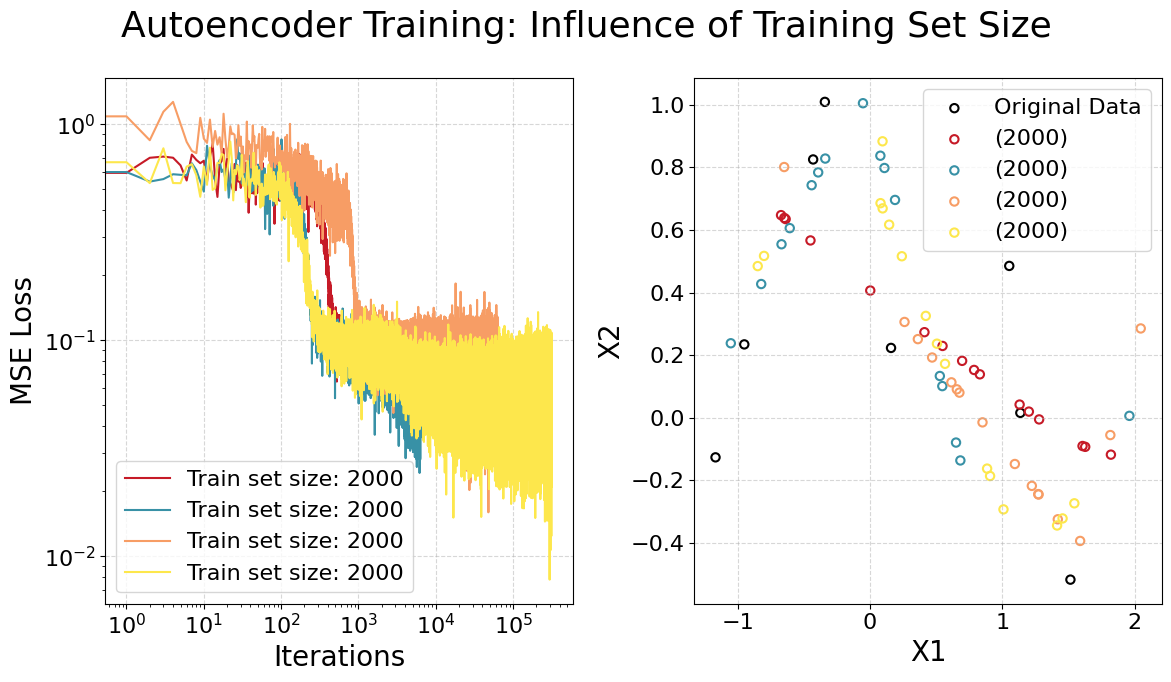

In [178]:
# Plot MSE loss for different training set sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Training Set Size", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Train set size: {params[0]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
#axes[0].set_title("MSE Loss vs Iterations for different Training Set Sizes")
axes[0].legend()
axes[0].loglog()
# Plot final reconstruction

# Get final output
final_epoch, X_batch, decoded = model_tss.outputs[-1]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"({results_tss[i][0][0]})", 
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
#axes[1].set_title("Final Reconstruction for different Training Set Sizes")
axes[1].legend()
plt.tight_layout()
plt.show()

Simply increasing the test size does obviously no good if the underlying network architecture is poor.

In [97]:
# 1 Investigate the influence of number of epochs given fixed other hyperparameters
hyperparameters_n_epochs = [(2000, 32, 10, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                            (2000, 32, 100, 0.001, 4, 2),
                            (2000, 32, 1000, 0.001, 4, 2),
                            (2000, 32, 5000, 0.001, 4, 2)]

results_tss = []
for params in hyperparameters_n_epochs:
    print(f"Training with training set size: {params[0]}, epochs: {params[2]}")
    # Create model
    model_n_epochs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_n_epochs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save results
    results_tss.append((params, model_n_epochs.train_losses, model_n_epochs.outputs[-1]))

Training with training set size: 2000, epochs: 10


100%|██████████| 10/10 [00:00<00:00, 10.12it/s]


Training with training set size: 2000, epochs: 100


100%|██████████| 100/100 [00:08<00:00, 12.21it/s]


Training with training set size: 2000, epochs: 1000


100%|██████████| 1000/1000 [01:20<00:00, 12.44it/s]


Training with training set size: 2000, epochs: 5000


100%|██████████| 5000/5000 [06:02<00:00, 13.80it/s]


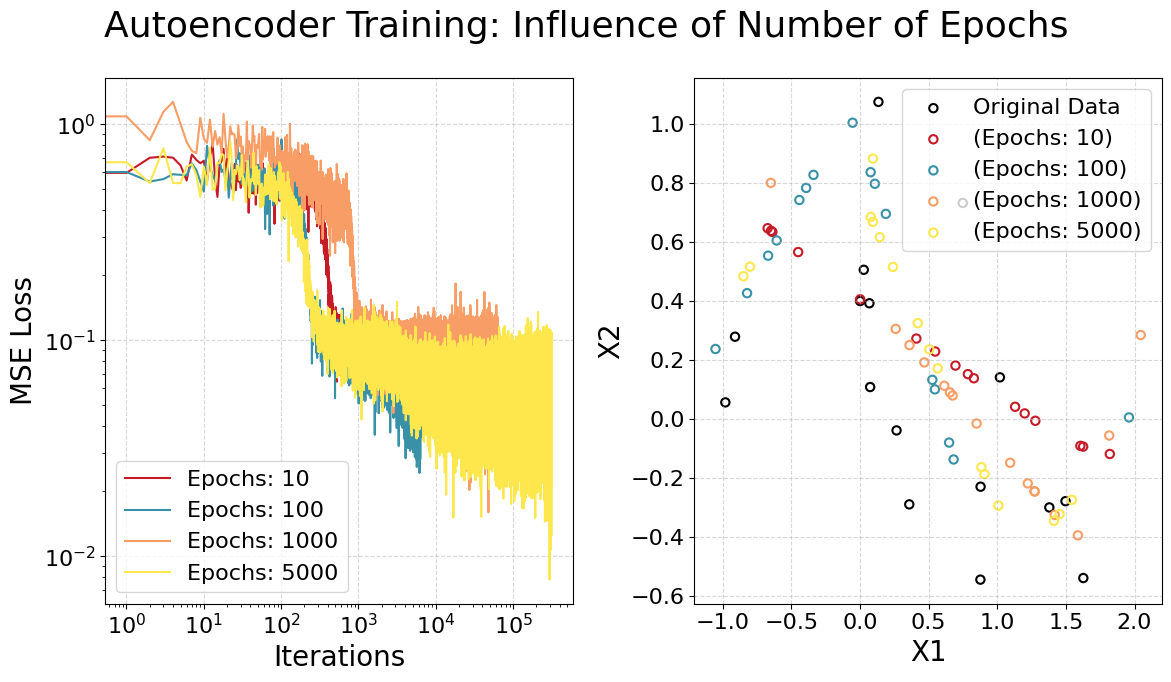

In [179]:
# Plot MSE loss for different number of epochs
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Number of Epochs", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Epochs: {params[2]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_tss[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epochs: {results_tss[i][0][2]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

Increasing the training iterations by brute force provides mixed and inconsistent results. In the left diagramm, one can seet the MSE loss shows a reduction between 100 and 1000 training iterations and the reconstructed data appears to be in the same order of magnitude as the data, in contrast to the sample where we simply increased the number of training points. Even the best results show a very linear trend and fail to capture the profile of the two moon samples. In some cases, the models trained for 1000 or 5000 epochs approximate the curved behavior with extra diagonal lines. However, our hypothesis is that this will not improve much until we expand the size of our network, as it currently only has 2 layers of dimension 4. Let's first test whether this can be improved by increasing the number of samples the model trains simultaneously from mini_batch_size = 32 -> 256.

In [99]:
# 1 Investigate the influence of mini-batch-size given fixed other hyperparameters
hyperparameters_mbs = [(2000, 32, 1000, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 64, 1000, 0.001, 4, 2),
                        (2000, 128, 1000, 0.001, 4, 2),
                        (2000, 256, 1000, 0.001, 4, 2)]

results_mbs = []
for params in hyperparameters_mbs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}")
    # Create model
    model_mbs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_mbs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_mbs.append((params, model_mbs.train_losses, model_mbs.outputs[-1]))

Training with training set size: 2000, n_epochs: 1000, mini batch size: 32


100%|██████████| 1000/1000 [01:12<00:00, 13.79it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 64


100%|██████████| 1000/1000 [00:39<00:00, 25.43it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 128


100%|██████████| 1000/1000 [00:24<00:00, 41.36it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 256


100%|██████████| 1000/1000 [00:16<00:00, 62.09it/s]


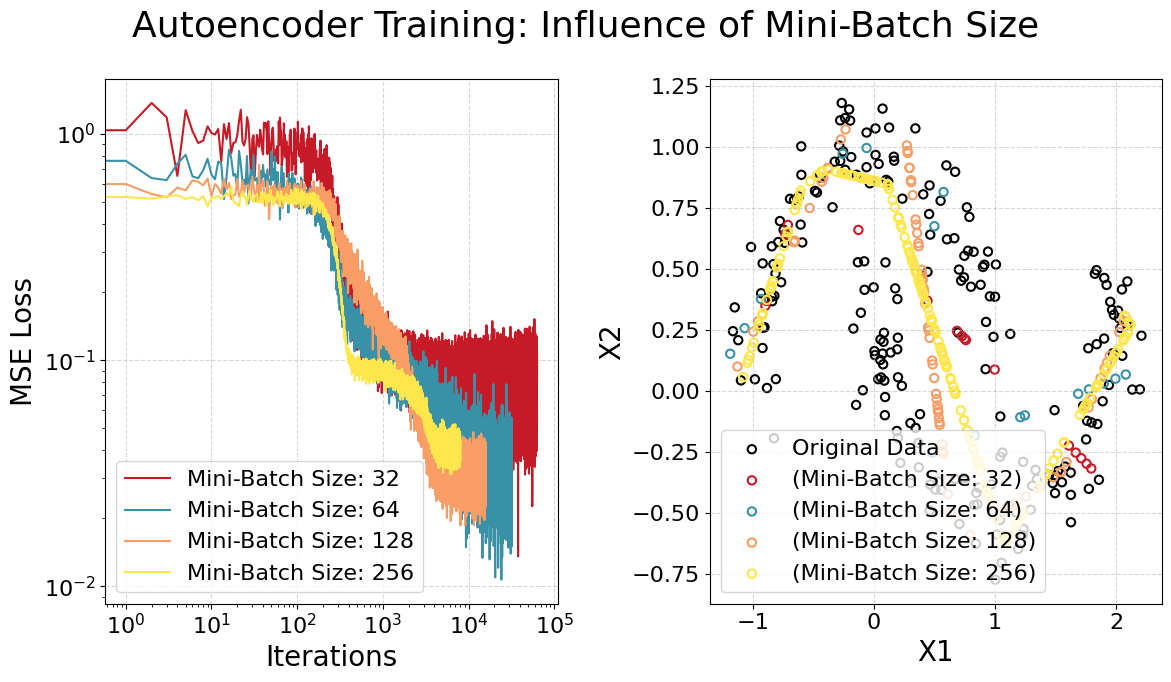

In [180]:
# Plot MSE loss for different mini-batch-sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Mini-Batch Size", fontsize=26)
# Plot training losses
for res in results_mbs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Mini-Batch Size: {params[1]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_mbs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_mbs)):
    final_epoch, X_batch, decoded = results_mbs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Mini-Batch Size: {results_mbs[i][0][1]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

As expected, increasing the test-points in every training iteration by using larger mini-batches provides inconsistent or at best marginally better results. Next we will test different network sizes. Since the data is relatively simple, increasing the number of layers beyond a certain extent will likely not provide significant results. Instead, it could cause issues due to vanishing gradients

In [101]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_lyrs = [(2000, 128, 2000, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 2000, 0.001, 4, 3),
                        (2000, 128, 2000, 0.001, 4, 4),
                        (2000, 128, 2000, 0.001, 4, 8)]

results_lyrs = []
for params in hyperparameters_lyrs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, layers: {params[5]}")
    # Create model
    model_lyrs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_lyrs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_lyrs.append((params, model_lyrs.train_losses, model_lyrs.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 2


100%|██████████| 2000/2000 [00:48<00:00, 40.93it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 3


100%|██████████| 2000/2000 [01:03<00:00, 31.51it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 4


100%|██████████| 2000/2000 [01:18<00:00, 25.43it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 8


100%|██████████| 2000/2000 [02:07<00:00, 15.63it/s]


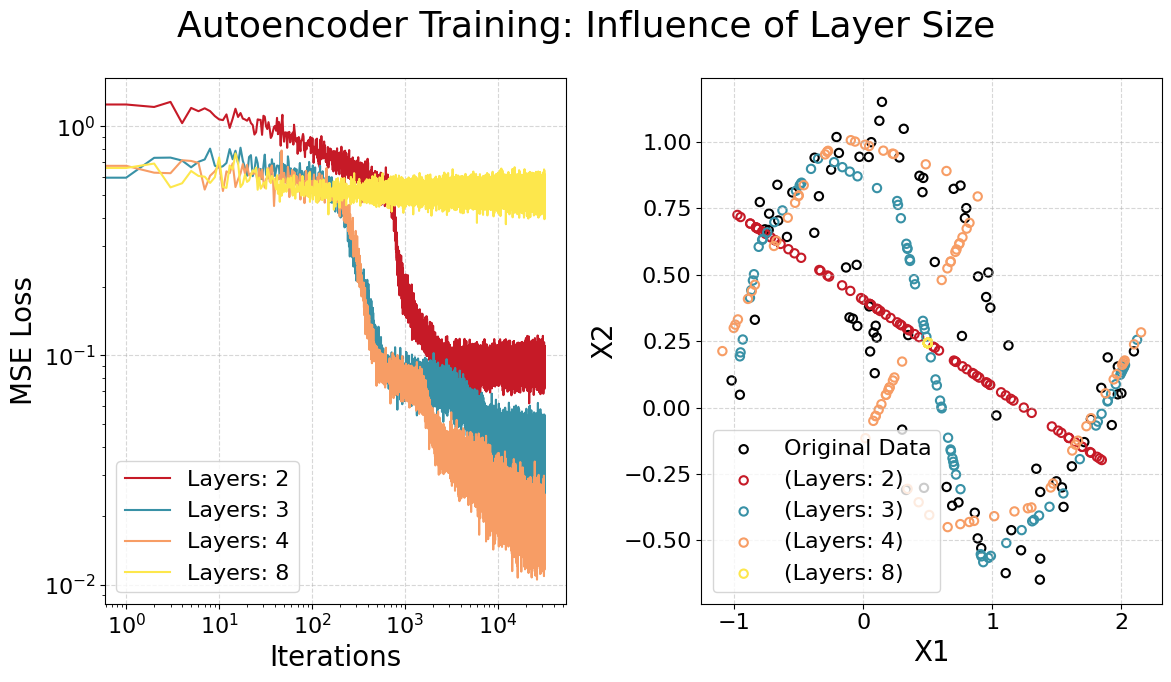

In [181]:
# Plot MSE loss for different layer-sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Layer Size", fontsize=26)
# Plot training losses
for res in results_lyrs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Layers: {params[5]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_lyrs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_lyrs)):
    final_epoch, X_batch, decoded = results_lyrs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Layers: {results_lyrs[i][0][5]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

Indeed, increasing the number of layers doesn't correlate with better performance. However, wider layers are more robust against vanishing layers and learn more features such as the curves of the two moons, the gap between them, etc. Likely this is the defining parameter between a model which kind of understands what it should be doing and one which does what it needs to do.

In [103]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_hsize = [(2000, 128, 2000, 0.001, 4, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 2000, 0.001, 8, 4),
                        (2000, 128, 2000, 0.001, 16, 4),
                        (2000, 128, 2000, 0.001, 32, 4)]

results_hsize = []
for params in hyperparameters_hsize:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_hsize = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_hsize.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_hsize.append((params, model_hsize.train_losses, model_hsize.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 4, layers: 4


100%|██████████| 2000/2000 [01:20<00:00, 24.92it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 8, layers: 4


100%|██████████| 2000/2000 [01:23<00:00, 23.97it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 2000/2000 [01:24<00:00, 23.72it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 32, layers: 4


100%|██████████| 2000/2000 [01:53<00:00, 17.55it/s]


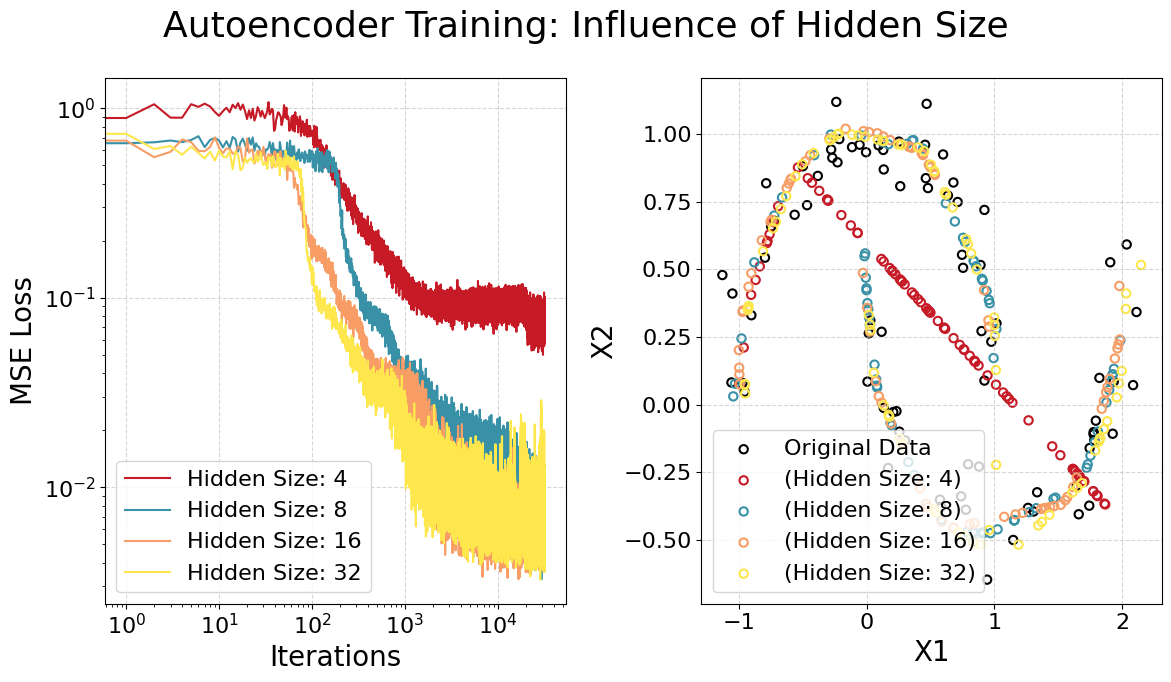

In [182]:
# Plot MSE loss for different hidden-sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Hidden Size", fontsize=26)
# Plot training losses
for res in results_hsize:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Hidden Size: {params[4]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_hsize[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_hsize)):
    final_epoch, X_batch, decoded = results_hsize[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Hidden Size: {results_hsize[i][0][4]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

Indeed! Upon visual inspection, the models are learning the nuances of the two moons data, in particularl adapting to the gap between the two moons (hidden size: 32) and following the curves more accurately (hidden size: 8+). Now, we would like to refine the rest of the hyperparameters. For example, the Loss diagram shows that there is still more room to let the model converge, so we should increase the number of iterations it trains for. We can also observe that the reconstruction loss has dipped below $10^{-2}$ for the first time.

In [105]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_refine_n_epochs = [(2000, 128, 2000, 0.001, 16, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 4000, 0.001, 16, 4),
                        (2000, 128, 8000, 0.001, 16, 4),
                        (2000, 128, 10000, 0.001, 16, 4)]

results_refine_n_epochs = []
for params in hyperparameters_refine_n_epochs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_n_epochs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_n_epochs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_n_epochs.append((params, model_refine_n_epochs.train_losses, model_refine_n_epochs.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 2000/2000 [01:20<00:00, 24.96it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:51<00:00, 23.30it/s]


Training with training set size: 2000, n_epochs: 8000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 8000/8000 [05:46<00:00, 23.08it/s]


Training with training set size: 2000, n_epochs: 10000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 10000/10000 [07:25<00:00, 22.46it/s]


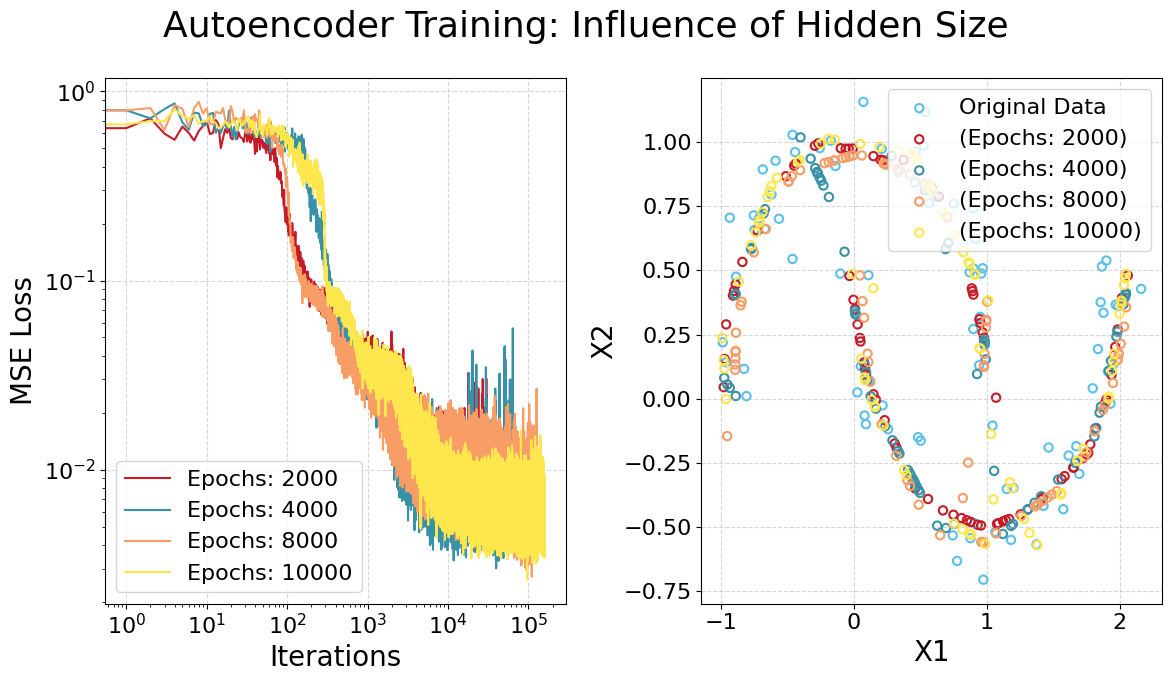

In [ ]:
# Plot MSE loss for different hidden-sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Hidden Size", fontsize=26)
# Plot training losses
for res in results_refine_n_epochs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Epochs: {params[2]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_refine_n_epochs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_refine_n_epochs)):
    final_epoch, X_batch, decoded = results_refine_n_epochs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epochs: {results_refine_n_epochs[i][0][2]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

There's no noticeable improvement beyond 2000-4000 training epochs. Next we'll try softer and more aggressive learning rates.

In [109]:
# 1 Investigate the influence of learning rates given fixed other hyperparameters
hyperparameters_refine_lr = [(2000, 128, 4000, 0.1, 16, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 4000, 0.01, 16, 4),
                        (2000, 128, 4000, 0.001, 16, 4),
                        (2000, 128, 4000, 0.0001, 16, 4)]

results_refine_lr = []
for params in hyperparameters_refine_lr:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_lr = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_lr.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_lr.append((params, model_refine_lr.train_losses, model_refine_lr.outputs[-1]))

Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:43<00:00, 24.46it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:55<00:00, 22.82it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:53<00:00, 23.00it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:56<00:00, 22.63it/s]


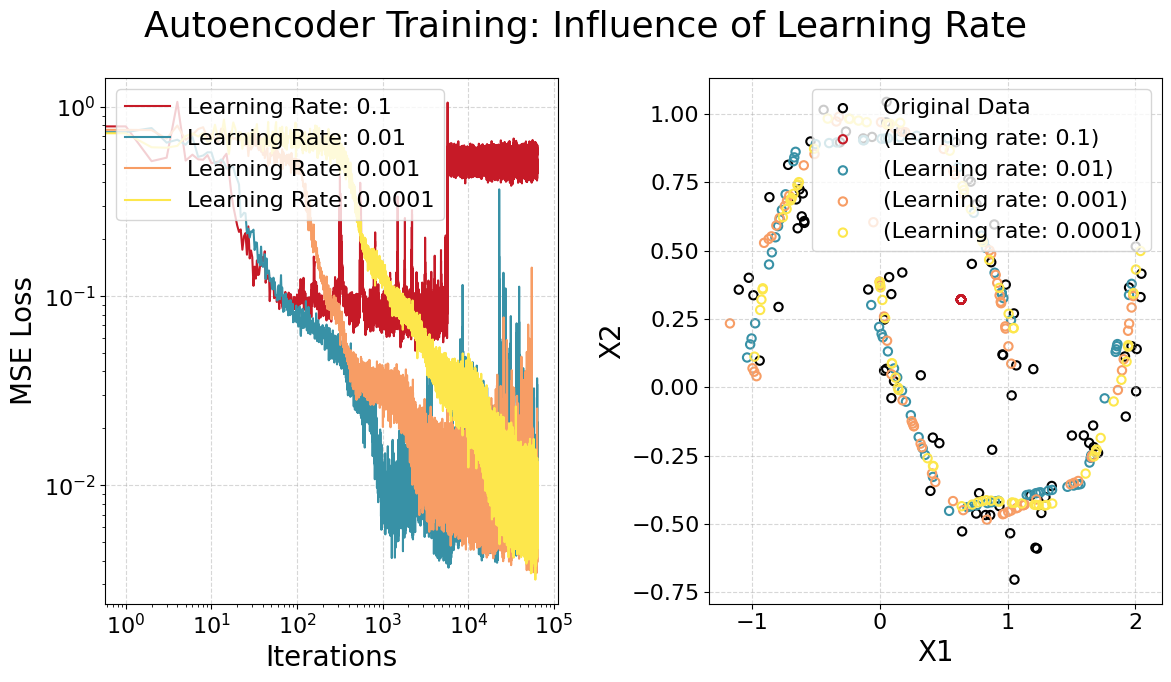

In [183]:
# Plot MSE loss for different learning rates
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Learning Rate", fontsize=26)
# Plot training losses
for res in results_refine_lr:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Learning Rate: {params[3]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_refine_lr[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_refine_lr)):
    final_epoch, X_batch, decoded = results_refine_lr[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Learning rate: {results_refine_lr[i][0][3]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

An aggressive learning rate of 0.1 seems to break down at some point, while smaller learning rates do comparatively well and similar to each other, except that a learning rate of 0.0001 simply takes longer to get there compared to 0.01 and 0.001. One could implement a learning schedule, but I think for our purposes with simple data this would be overkill. Instead, we'll stick to a learning rate between 0.01 - 0.001. Now let's try to economize and cut corners where we may have initially overcompensated. For example, we chose 4 hidden layers because it worked best when there were 4 neurons each. Then we settled on 16 neurons each without adjusting the number of layers.

In [129]:
# 1 Investigate the influence of learning rates given fixed other hyperparameters
hyperparameters_refine_hs_lyrs = [(2000, 128, 2000, 0.005, 16, 4),
                                  (2000, 128, 2000, 0.005, 12, 4),
                                  (2000, 128, 2000, 0.005, 16, 3), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                                  (2000, 128, 2000, 0.005, 12, 3),
                                  (2000, 128, 2000, 0.005, 16, 2),
                                  (2000, 128, 2000, 0.005, 12, 2),
                                  #(2000, 128, 2000, 0.005, 8, 2),
                                  #(2000, 128, 2000, 0.005, 6, 2)
                                  ]

results_refine_hs_lyrs = []
for params in hyperparameters_refine_hs_lyrs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_hs_lyrs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_hs_lyrs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_hs_lyrs.append((params, model_refine_hs_lyrs.train_losses, model_refine_hs_lyrs.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 2000/2000 [01:13<00:00, 27.13it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 12, layers: 4


100%|██████████| 2000/2000 [01:24<00:00, 23.76it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 3


100%|██████████| 2000/2000 [01:14<00:00, 27.00it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 12, layers: 3


100%|██████████| 2000/2000 [01:18<00:00, 25.38it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 2


100%|██████████| 2000/2000 [01:06<00:00, 29.85it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 12, layers: 2


100%|██████████| 2000/2000 [01:07<00:00, 29.53it/s]


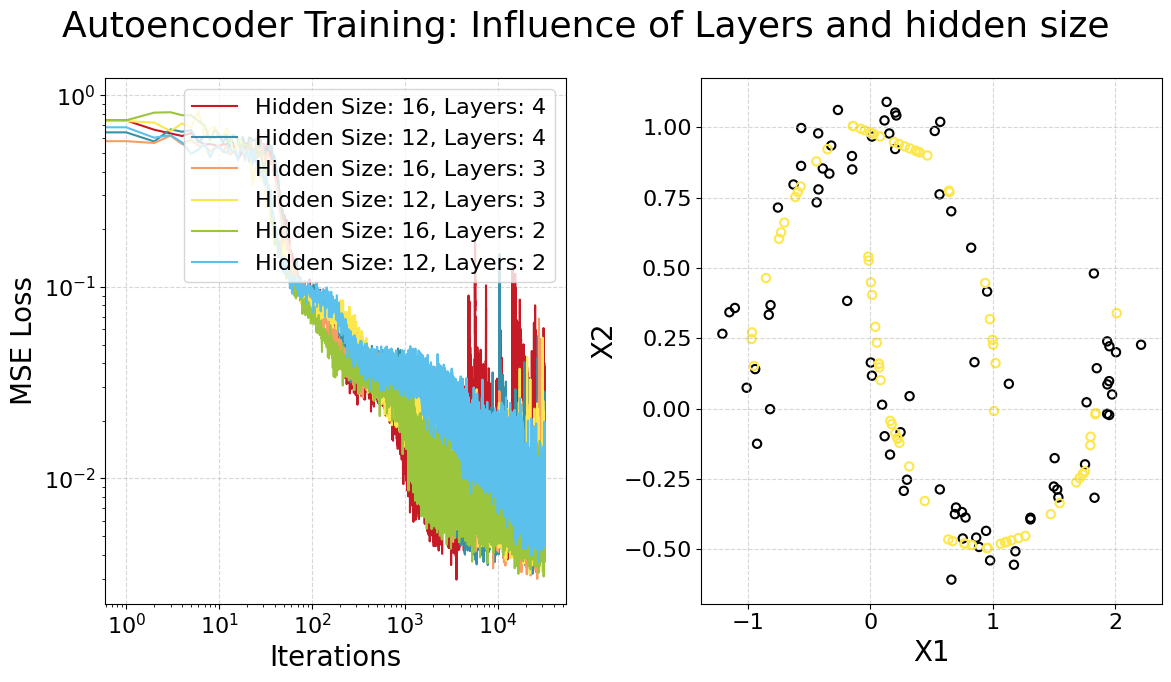

In [177]:
# Plot MSE loss for different learning rates
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Layers and hidden size", fontsize=26)
# Plot training losses
for res in results_refine_hs_lyrs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Hidden Size: {params[4]}, Layers: {params[5]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_refine_hs_lyrs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_refine_hs_lyrs)):
    if i in [1, 2, 0, 4, 5]:
        continue
    final_epoch, X_batch, decoded = results_refine_hs_lyrs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Hidden size: {results_refine_hs_lyrs[i][0][4]}, Layers: {results_refine_hs_lyrs[i][0][5]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
#axes[1].legend()
plt.tight_layout()
plt.show()

While reducing the number of neurons and layers still yields recognizable results, the lines get smoother and smoother for a wider and slightly deeper architecture. We find the best combination of depth and width to be 3 layers of 16 neurons each.

## 2. Two-dimensional data without bottleneck

We remove the bottleneck which would usually force the network to focus on the important features. To counteract this, we introduce an additional loss term. We use MMD between the code distribution (push-forward through the encoder) and a two-dimensional standard normal.

The kernel for the MMD shall be a sum of squared exponentials or inverse multiquadratics at multiple bandwidths (hyperparameter). We use the Autoencoder from task 1 with bottleneck_size = 2.

In [276]:
# Train Autoencoder with bottleneck_size = 2 using MMD loss
model_mmd = Autoencoder(input_size = 2,
                        bottleneck_size = 2,
                        hidden_size = 16,
                        layers = 3)
model_mmd.train_mmd_autoencoder(X_train,
                                training_set_size = 2000,
                                mini_batch_size = 128,
                                n_epochs = 2000,
                                learning_rate = 0.005,
                                mmd_kernel = "squared_exponential",
                                mmd_bandwidths = [0.05, 0.1, 0.2, 0.4, 0.8, 1.6, 3.2],
                                lambda_mmd = 1)

100%|██████████| 2000/2000 [07:46<00:00,  4.29it/s]


1


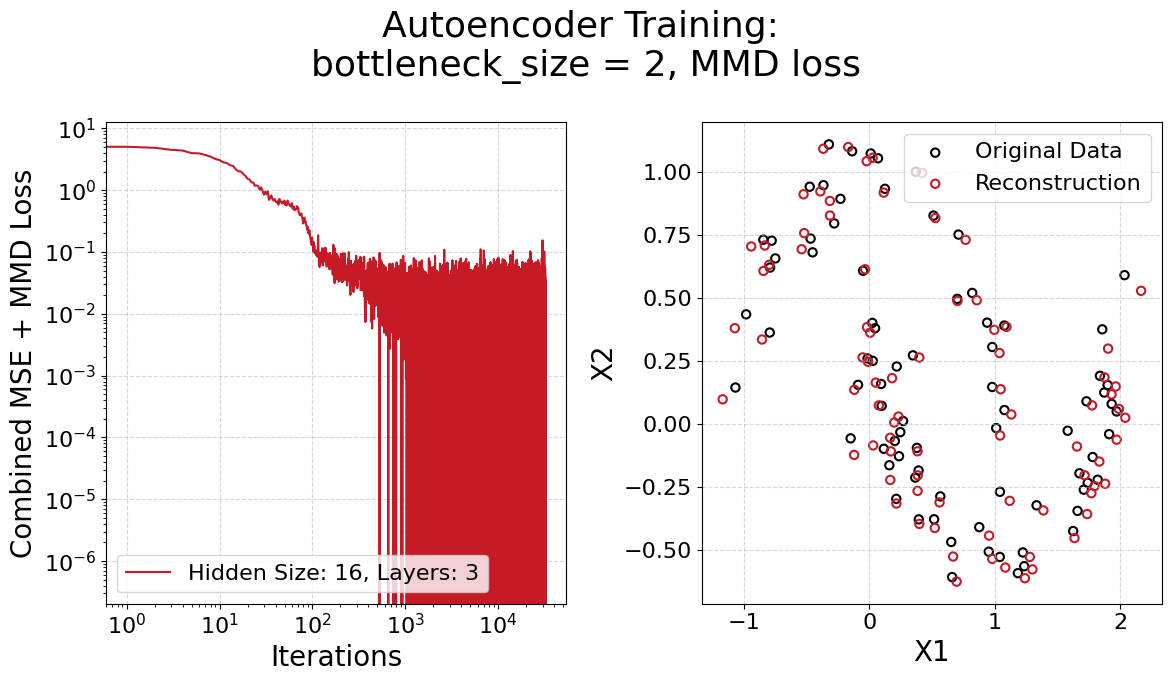

In [277]:
params = (2000, 128, 2000, 0.005, 16, 3)
results_mmd_losses = []
results_mmd_losses.append((params, model_mmd.train_losses, model_mmd.outputs[-1]))
# Plot loss for MMD Autoencoder
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: \nbottleneck_size = 2, MMD loss", fontsize=26)
# Plot training losses
for res in results_mmd_losses:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Hidden Size: {params[4]}, Layers: {params[5]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Combined MSE + MMD Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_mmd_losses[-1][2]
print(len(results_mmd_losses))
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_mmd_losses)):
    final_epoch, X_batch, decoded = results_mmd_losses[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"Reconstruction", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

As predicted in the exercise description, the reconstruction error is much less ($\approx10^{-4}$) than in exercise 1 with a `bottleneck_size = 2`. Additionally, plotting the batch data with the corresponding reconstructed points shows how the data has been almost perfectly reconstructed. This learning process is also extremely quick, almost perfectly reconstructing the sample data after less than 20 iterations. Further refinement does take a couple of hundred - thousand epochs of training. 

One can also remark that in comparison to `bottleneck_size = 1`, which only provided a 1-dimensional curve, the new distribution is 2-dimensional.

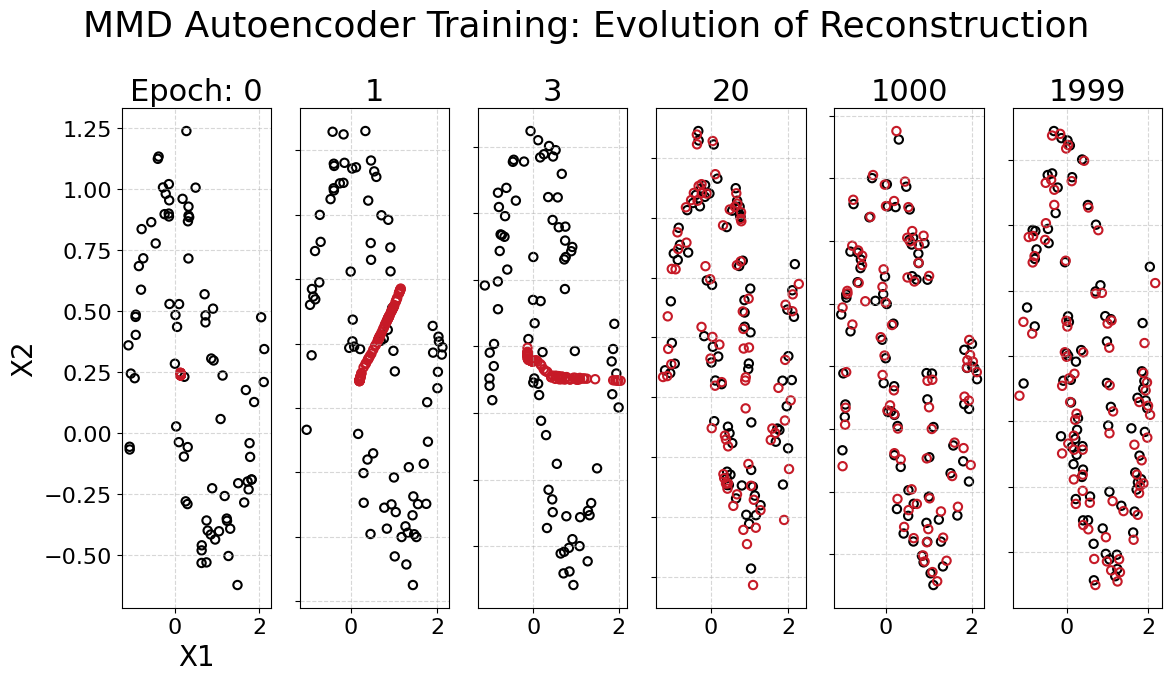

In [278]:
fig, axes = plt.subplots(1, 6)
fig.suptitle("MMD Autoencoder Training: Evolution of Reconstruction", fontsize=26)
indices = [-2000, -1999, -1997, -1980, -1000, -1]
for i, idx in enumerate(indices):
    final_epoch, X_batch, decoded = model_mmd.outputs[idx]
    axes[i].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                    label="Original Data", 
                    color = "black")
    axes[i].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epoch: {final_epoch})", 
                    alpha=1,
                    color = colors[0])


    axes[i].tick_params(labelleft=False)
    if i == 0:
        axes[i].set_xlabel("X1")
        axes[i].set_ylabel("X2")
        axes[i].tick_params(labelleft=True)
        axes[i].set_title(f"Epoch: {final_epoch}")
    else:
        axes[i].set_title(f"{final_epoch}")
plt.tight_layout()
plt.show()


We now want to corroborate that the code distribution after the encoder resembles a standard Gaussian. Superimposing the results over samples from a standard Gaussian shows great results. Calculating the mean and covariance of the code distribution also yields 

T-test results for X1: t-statistic = 0.024092652964352607, p-value = 0.9807811095550562
T-test results for X2: t-statistic = -3.2402617193968934, p-value = 0.0012138213905118105


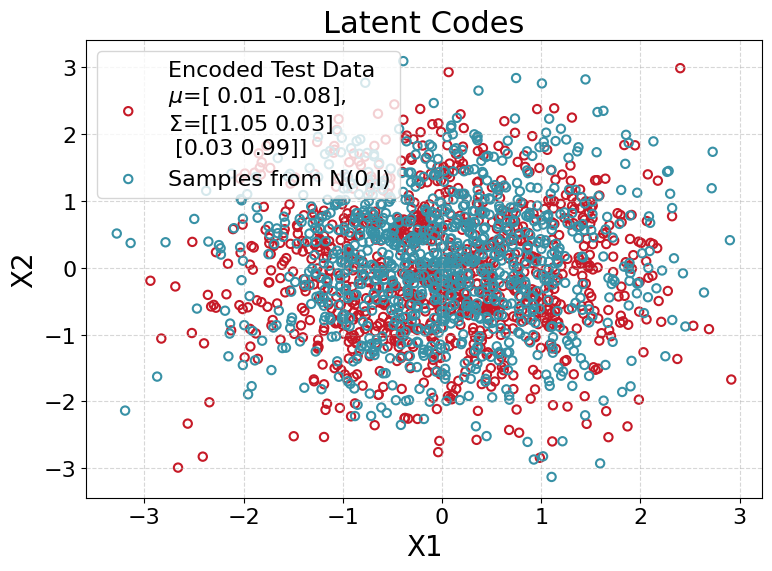

In [303]:
# Generate samples from 2d standard normal
normal_samples = torch.randn((1000, 2))

# Plot codes after training MMD Autoencoder
with torch.no_grad():
    codes = X_test[:1000]
    for layer in model_mmd.encoder:
       codes = layer(codes)

       # Calculate mean and covariance of codes
       mu = torch.mean(codes, dim=0)
       cov = torch.cov(codes.T)

# Calculate t-test to see if codes and samples are from same distribution
from scipy.stats import ttest_ind
t_statistic_x1, p_value_x1 = ttest_ind(codes[:, 0], normal_samples[:, 0])
t_statistic_x2, p_value_x2 = ttest_ind(codes[:, 1], normal_samples[:, 1])
print(f"T-test results for X1: t-statistic = {t_statistic_x1}, p-value = {p_value_x1}")
print(f"T-test results for X2: t-statistic = {t_statistic_x2}, p-value = {p_value_x2}")

fig = plt.figure(figsize=(8, 6))
plt.scatter(codes[:, 0].detach().numpy(), codes[:, 1].detach().numpy(), alpha=1, 
            label = f"Encoded Test Data\n$\mu$={mu.detach().numpy().round(2)}, \n$\Sigma$={cov.detach().numpy().round(2)}")
plt.scatter(normal_samples[:, 0].detach().numpy(), normal_samples[:, 1].detach().numpy(), alpha=1, label = "Samples from N(0,I)")
plt.title("Latent Codes")
plt.legend()
plt.xlabel("X1")
plt.ylabel("X2")
plt.tight_layout()
plt.show()

Next we investigate briefly the influence of the weight of the MMD^2 Loss term. Starting with $\lambda_{MMD} = 1$ to $1000$, training for 1000 epochs each, we see the 

In [ ]:
# 1 Investigate the influence of lambda weights fixed other hyperparameters
MMD_weights = [1, 5, 10, 20, 50, 100, 500, 1000]

results_MMD_weights = []
params = (2000, 128, 1000, 0.005, 16, 3)
for weight in MMD_weights:
    print(f"Training with MMD weight: {weight}")
    # Create model
    model_MMD_w = Autoencoder(input_size=2, 
                        bottleneck_size=2, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_MMD_w.train_mmd_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3],
                            mmd_kernel = "inverse_multi_quadratic",
                            mmd_bandwidths = [0.05, 0.1, 0.2, 0.4, 0.8, 1.6, 3.2],
                            lambda_mmd = weight)
    # Save result
    results_MMD_weights.append((params, model_MMD_w.train_losses, model_MMD_w)) # OJO here changed to save model instead of only outputs

Training with MMD weight: 1


100%|██████████| 1000/1000 [06:45<00:00,  2.47it/s]


Training with MMD weight: 5


100%|██████████| 1000/1000 [03:35<00:00,  4.65it/s]


Training with MMD weight: 10


100%|██████████| 1000/1000 [03:47<00:00,  4.39it/s]


Training with MMD weight: 20


100%|██████████| 1000/1000 [03:53<00:00,  4.28it/s]


Training with MMD weight: 50


100%|██████████| 1000/1000 [03:56<00:00,  4.22it/s]


Training with MMD weight: 100


100%|██████████| 1000/1000 [03:56<00:00,  4.23it/s]


Training with MMD weight: 500


100%|██████████| 1000/1000 [03:56<00:00,  4.23it/s]


Training with MMD weight: 1000


100%|██████████| 1000/1000 [04:02<00:00,  4.13it/s]


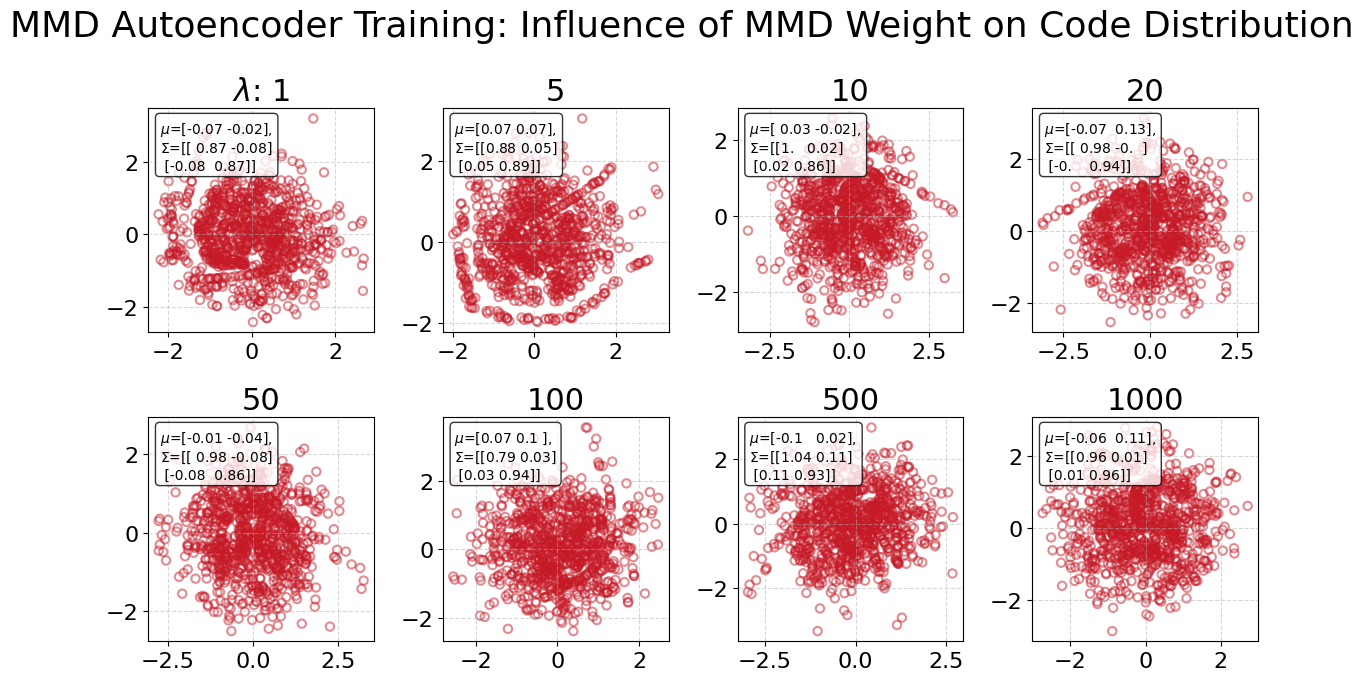

In [319]:
# Plot code distribution for different MMD weights
fig, axes = plt.subplots(2, 4)
fig.suptitle("MMD Autoencoder Training: Influence of MMD Weight on Code Distribution", fontsize=26)
# Plot code distributions

for i in range(len(results_MMD_weights)):
    with torch.no_grad():
        codes = X_test[:1000]
        model = results_MMD_weights[i][2]
        for layer in model.encoder:
            codes = layer(codes)

    # Calculate mean and covariance of codes
    mu = torch.mean(codes, dim=0)
    cov = torch.cov(codes.T)

    axes[i // 4, i % 4].scatter(codes[:, 0].detach().numpy(), codes[:, 1].detach().numpy(),
                    alpha = 0.5)
    label = f"$\mu$={mu.detach().numpy().round(2)}, \n$\Sigma$={cov.detach().numpy().round(2)}"
    axes[i // 4, i % 4].text(0.05, 0.95, label, transform=axes[i // 4, i % 4].transAxes,
                fontsize=10, verticalalignment='top', bbox=textbox_style)

    if i == 0:
        axes[i // 4, i % 4].set_title(f"$\lambda$: {MMD_weights[i]}")
    else:
        axes[i // 4, i % 4].set_title(f"{MMD_weights[i]}")
        
plt.tight_layout()
plt.show()

As we see, for larger weights of the MMD$^2$ loss, the distribution approaches more closely a standard normal. However, as we can also see in the next plots, the reconstruction becomes worse as well. There is a balance which must be kept between reconstruction and MMD$^2$ error. 

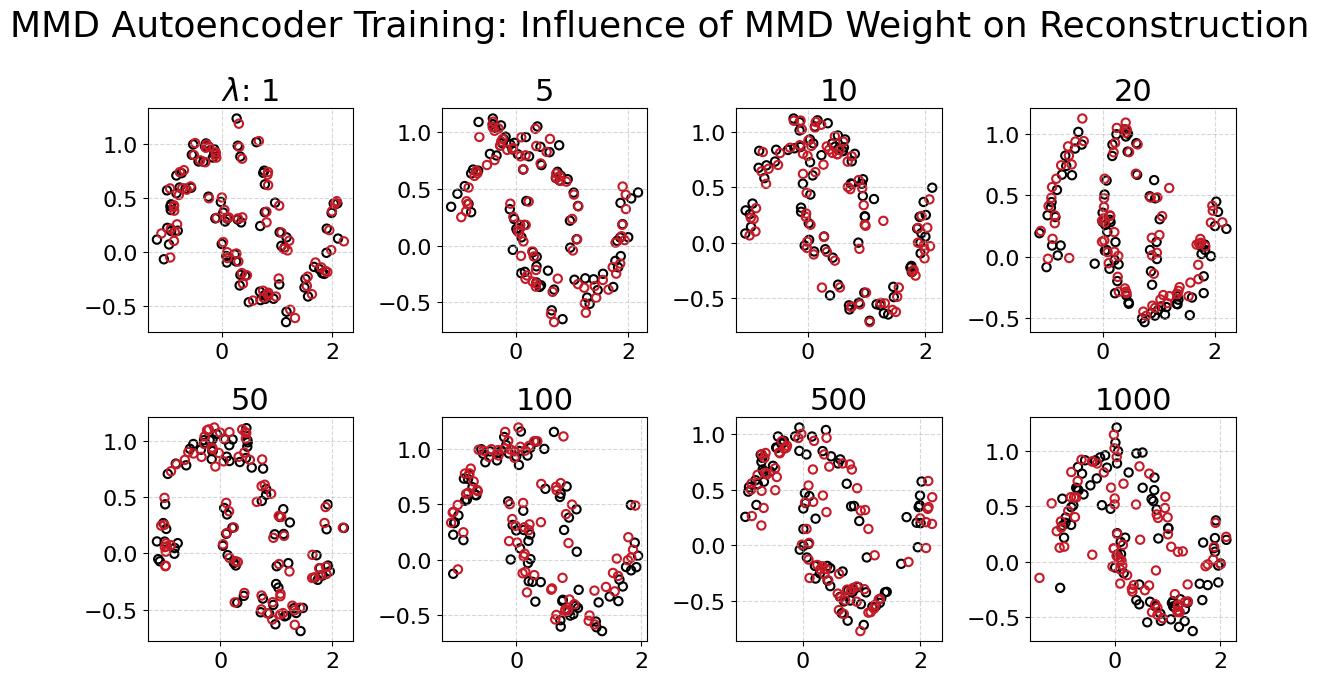

In [ ]:
# Plot reconstruction for different MMD weights
fig, axes = plt.subplots(2, 4)
fig.suptitle("MMD Autoencoder Training: Influence of MMD Weight on Reconstruction", fontsize=26)
# Plot code distributions

for i in range(len(results_MMD_weights)):
    with torch.no_grad():
        final_epoch, X_batch, decoded = results_MMD_weights[i][2].outputs[-1]
        axes[i // 4, i % 4].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                        label="Original Data", 
                        color = "black")
        axes[i // 4, i % 4].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                        label=f"(Epoch: {final_epoch})", 
                        alpha=1,
                        color = colors[0])

    #axes[i // 4, i % 4].tick_params(labelleft=False)
    if i == 0:
        #axes[i // 4, i % 4].set_xlabel("X1")
        #axes[i // 4, i % 4].set_ylabel("X2")
        #axes[i // 4, i % 4].tick_params(labelleft=True)
        axes[i // 4, i % 4].set_title(f"$\lambda$: {MMD_weights[i]}")
    else:
        axes[i // 4, i % 4].set_title(f"{MMD_weights[i]}")
        
plt.tight_layout()
plt.show()

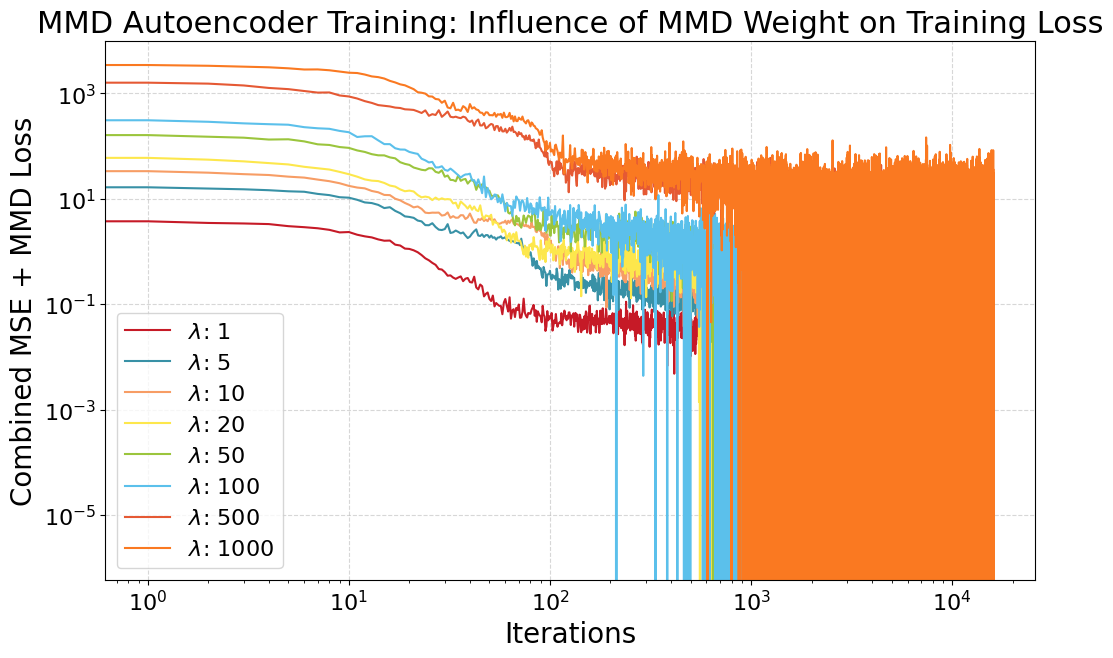

In [287]:
# Plot the training losses for different MMD weights
plt.figure()
for res in results_MMD_weights:
    params, train_losses, _ = res
    plt.plot(train_losses, label=f"$\lambda$: {MMD_weights[results_MMD_weights.index(res)]}")
plt.xlabel("Iterations")
plt.ylabel("Combined MSE + MMD Loss")
plt.title("MMD Autoencoder Training: Influence of MMD Weight on Training Loss")
plt.loglog()
plt.legend()
plt.show()

## 3. Higher-dimensional data

In [342]:
# Test AE code with bottleneck sizes 2, 4, 8 on MNIST dataset
from sklearn.datasets import load_digits
digits = load_digits()
X_mnist = digits.data / 16.0  # Normalize pixel values to [0, 1]
y_mnist = digits.target
X_mnist = torch.tensor(X_mnist, dtype=torch.float32)
y_mnist = torch.tensor(y_mnist, dtype=torch.long)
from sklearn.model_selection import train_test_split
X_mnist_train, X_mnist_test, y_mnist_train, y_mnist_test = train_test_split(X_mnist, y_mnist, test_size=0.2, random_state=42)

In Ex. 1 we saw that the hyperparameters that have the biggest influence are network size and depth, mini-batch size and training time/epochs. So we will only investigate these.

In [378]:
# Show sample of mnist digit reconstruction for bottleneck_sizes 2,4,8
bottleneck_sizes = [2, 4, 8]
reconstruction_results = []
params = [10000, 256, 200, 0.001, 32, 2] # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers

for size in bottleneck_sizes:
    print(f"Training with bottleneck size: {size}")

    model_size = Autoencoder(
        input_size=64,
        bottleneck_size=size,
        hidden_size=params[4],
        layers=params[5]
    )

    model_size.train_autoencoder(X_mnist_train,
                                training_set_size=params[0],
                                n_epochs=params[2],
                                mini_batch_size=params[1],
                                learning_rate=params[3]
)

    reconstruction_results.append((size, model_size.train_losses, model_size))
    print(f"Loss: {model_size.train_losses[-1]}, for bottleneck size: {size}")

Training with bottleneck size: 2


100%|██████████| 200/200 [00:04<00:00, 42.94it/s]


Loss: 0.03675268217921257, for bottleneck size: 2
Training with bottleneck size: 4


100%|██████████| 200/200 [00:03<00:00, 53.73it/s]


Loss: 0.02747570350766182, for bottleneck size: 4
Training with bottleneck size: 8


100%|██████████| 200/200 [00:03<00:00, 52.22it/s]

Loss: 0.020401477813720703, for bottleneck size: 8


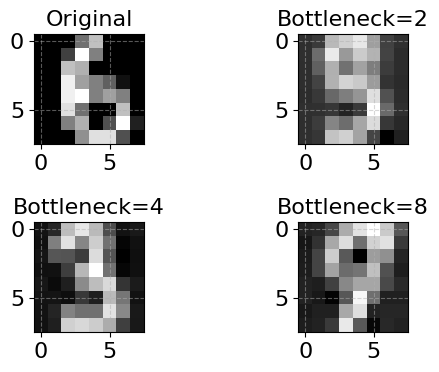

In [ ]:
# Show reconstruction results for bottleneck_sizes 2,4,8
for size, losses, model in reconstruction_results:
    # Get some test samples and their reconstructions
    with torch.no_grad():
        test_samples = X_mnist_test[:4]
        reconstructed_samples = model.forward(test_samples)
    
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
for i in range(4):
    if i == 0:
        axes[i//2, i%2].set_title("Original", fontsize=16)
        axes[i//2, i%2].imshow(test_samples[i].reshape(8, 8), cmap='gray')
    else:
        axes[i//2, i%2].imshow(reconstructed_samples[i].reshape(8, 8), cmap='gray')
        axes[i//2, i%2].set_title(f"Bottleneck={bottleneck_sizes[i - 1]}", fontsize=16)

plt.tight_layout()
plt.show()

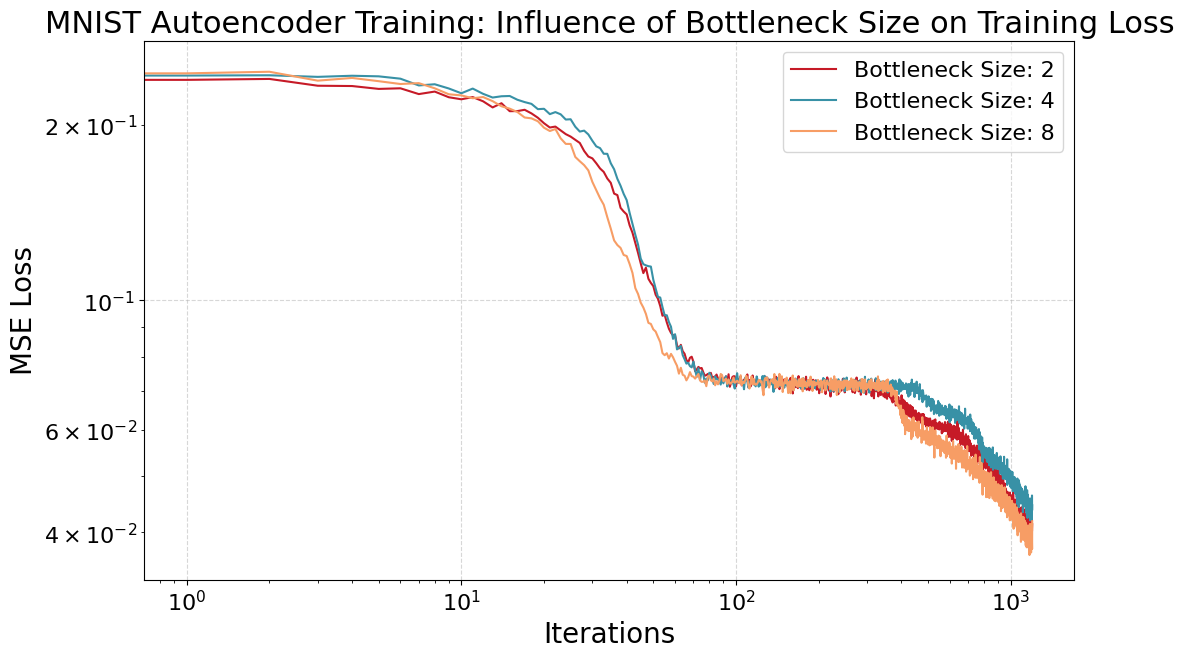

In [383]:
# Plot MSE loss for MMD Autoencoder
plt.figure()
for res in reconstruction_results:
    size, train_losses, _ = res
    plt.plot(train_losses, label=f"Bottleneck Size: {size}")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("MNIST Autoencoder Training: Influence of Bottleneck Size on Training Loss")
plt.loglog()
plt.legend()
plt.show()

In [386]:
# layers Show sample of mnist digit reconstruction for bottleneck_sizes 2,4,8
bottleneck_sizes = [2, 4, 8]
reconstruction_results = []
params = [10000, 256, 200, 0.001, 32, 4] # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers

for size in bottleneck_sizes:
    print(f"Training with bottleneck size: {size}")

    model_size = Autoencoder(
        input_size=64,
        bottleneck_size=size,
        hidden_size=params[4],
        layers=params[5]
    )

    model_size.train_autoencoder(X_mnist_train,
                                training_set_size=params[0],
                                n_epochs=params[2],
                                mini_batch_size=params[1],
                                learning_rate=params[3]
)

    reconstruction_results.append((size, model_size.train_losses, model_size))

Training with bottleneck size: 2


100%|██████████| 200/200 [00:05<00:00, 37.59it/s]


Training with bottleneck size: 4


100%|██████████| 200/200 [00:05<00:00, 39.61it/s]


Training with bottleneck size: 8


100%|██████████| 200/200 [00:04<00:00, 43.44it/s]


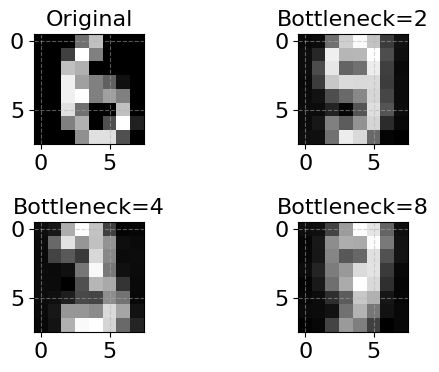

In [387]:
# Show reconstruction results for bottleneck_sizes 2,4,8
for size, losses, model in reconstruction_results:
    # Get some test samples and their reconstructions
    with torch.no_grad():
        test_samples = X_mnist_test[:4]
        reconstructed_samples = model.forward(test_samples)
    
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
for i in range(4):
    if i == 0:
        axes[i//2, i%2].set_title("Original", fontsize=16)
        axes[i//2, i%2].imshow(test_samples[i].reshape(8, 8), cmap='gray')
    else:
        axes[i//2, i%2].imshow(reconstructed_samples[i].reshape(8, 8), cmap='gray')
        axes[i//2, i%2].set_title(f"Bottleneck={bottleneck_sizes[i - 1]}", fontsize=16)

plt.tight_layout()
plt.show()

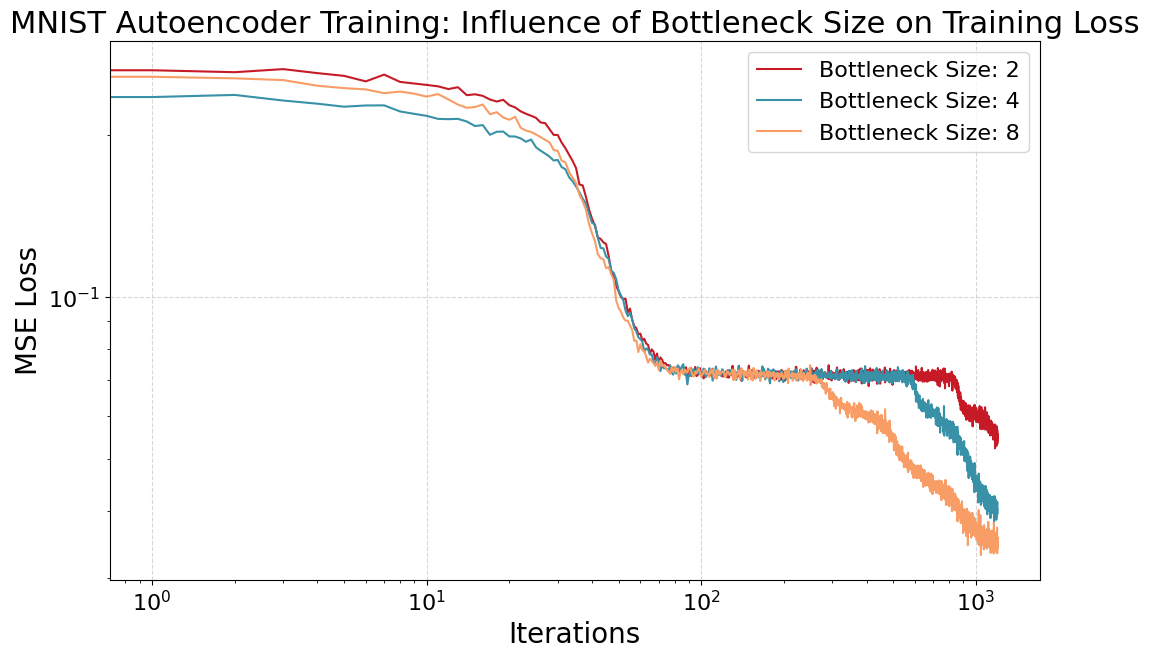

In [388]:
# Plot MSE loss for MMD Autoencoder
plt.figure()
for res in reconstruction_results:
    size, train_losses, _ = res
    plt.plot(train_losses, label=f"Bottleneck Size: {size}")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("MNIST Autoencoder Training: Influence of Bottleneck Size on Training Loss")
plt.loglog()
plt.legend()
plt.show()

We settle on a specific architecture and move on from there

In [360]:
bottleneck_sizes = [2, 4, 8]
results_mnist = []
params = [5000, 128, 500, 0.001, 256, 2]

for size in bottleneck_sizes:
    model_mnist = Autoencoder(input_size=64, 
                            bottleneck_size=size, 
                            hidden_size=params[4], 
                            layers=params[5])
    model_mnist.train_autoencoder(X_mnist_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    results_mnist.append((size, model_mnist.train_losses, model_mnist))


100%|██████████| 500/500 [00:45<00:00, 11.10it/s]


Now we train a Random Forest Classifier and check if the predicted labels from our different models

In [343]:
# Train Random Forest Classifier on data, use it to classify reconstructions
# Save weights of the classifier for later use
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_mnist_train.numpy(), y_mnist_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


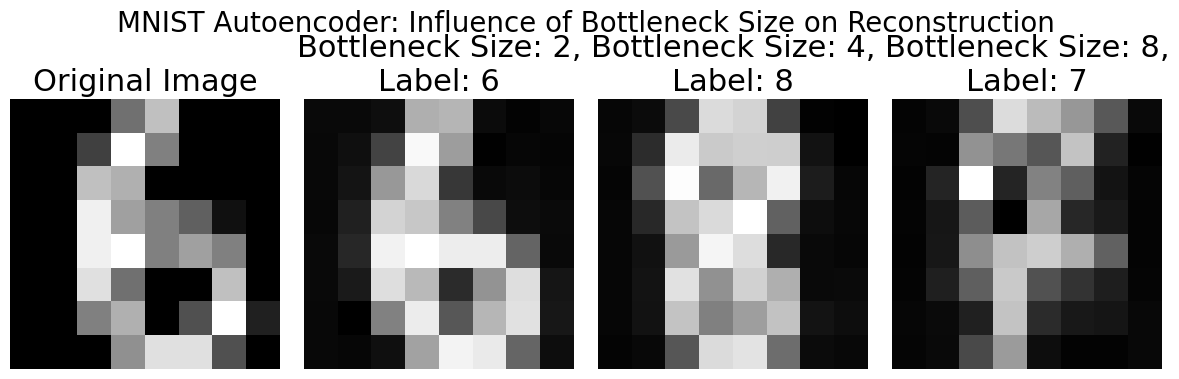

In [361]:
# Check reconstruction for different bottleneck sizes
fig, axes = plt.subplots(1, len(bottleneck_sizes) + 1, figsize=(12, 4))
fig.suptitle("MNIST Autoencoder: Influence of Bottleneck Size on Reconstruction", fontsize=20)
# Original image
original_image = X_mnist_test[0].reshape(8, 8)
axes[0].imshow(original_image.detach().numpy(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Reconstructed images
for i in range(len(results_mnist)):
    size, _, model = results_mnist[i]
    with torch.no_grad():
        code = X_mnist_test[torch.randint(0, X_mnist_test.size(0), (1,))].unsqueeze(0)
        decoded = model.forward(code)

    reconstructed_image = decoded.reshape(8, 8)
    # Predict label with RF classifier
    #print(reconstructed_image.shape)
    #print(decoded.detach().numpy())
    predicted_label = rf_classifier.predict(decoded.numpy().reshape(1, -1))
    #print(f"Bottleneck: {size}, \nLabel: {predicted_label[0]}")
    axes[i + 1].imshow(reconstructed_image.detach().numpy(), cmap='gray')
    axes[i + 1].set_title(f"Bottleneck Size: {size},\nLabel: {predicted_label[0]}")
    axes[i + 1].axis('off')
plt.tight_layout()
plt.show()

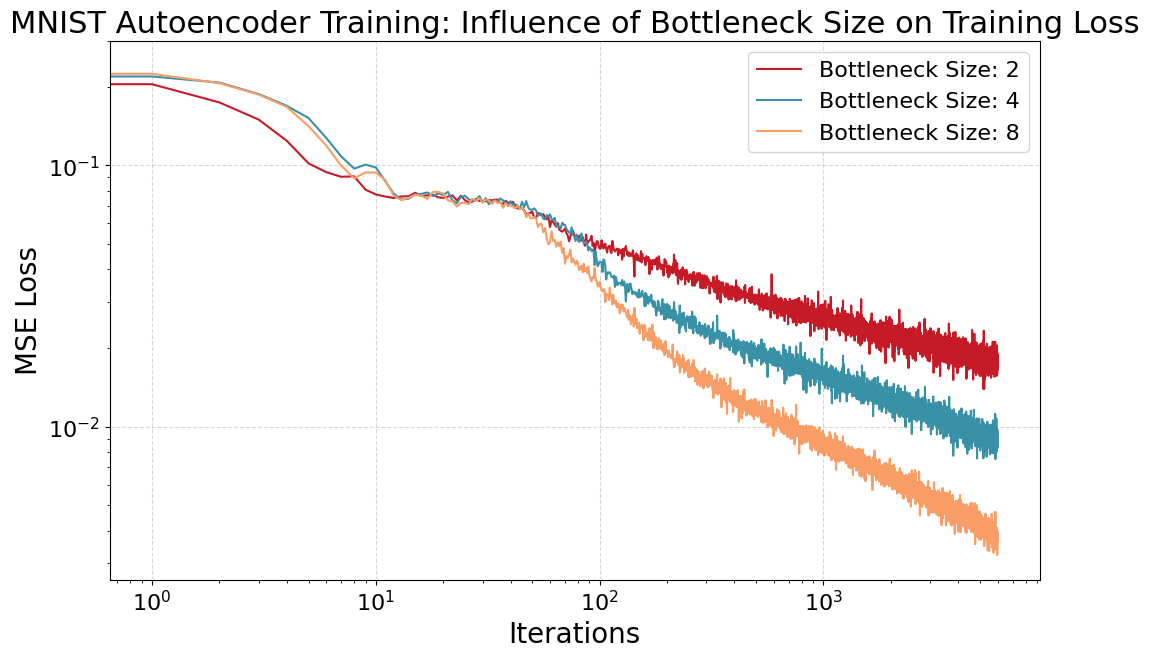

In [362]:
# Plot MSE loss for MMD Autoencoder
plt.figure()
for res in results_mnist:
    size, train_losses, _ = res
    plt.plot(train_losses, label=f"Bottleneck Size: {size}")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("MNIST Autoencoder Training: Influence of Bottleneck Size on Training Loss")
plt.loglog()
plt.legend()
plt.show()

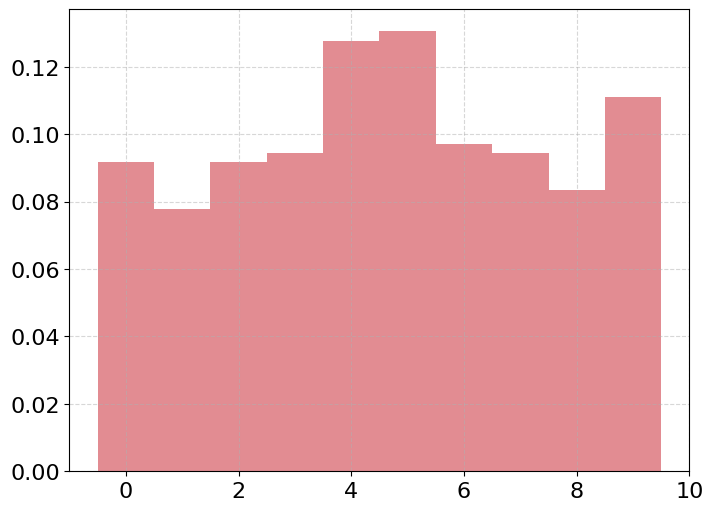

In [389]:
# Classify the reconstructions
predictions_mnist = []
for res in results_mnist:
    size, _, model = res
    with torch.no_grad():
        decoded = model.forward(X_mnist_test)
    preds = rf_classifier.predict(decoded.numpy())
    predictions_mnist.append((size, preds))

# Plot histogram prediction
plt.figure(figsize = (8,6))
plt.hist(y_mnist_test.numpy(), torch.arange(11)-0.5, alpha=0.5, label="True Labels", density=True)
plt.show()

Text(0, 0.5, 'Z2')

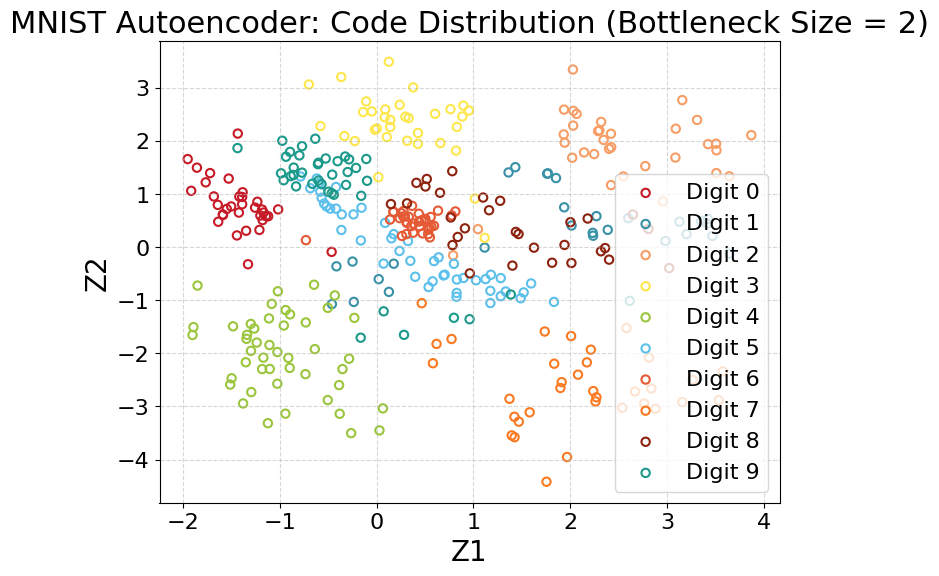

In [372]:
# Visualize code distribution for bottleneck_size = 2
with torch.no_grad():
    codes = X_mnist_test
    for layer in results_mnist[0][2].encoder:
        codes = layer(codes)

codes_np = codes.numpy()
plt.figure(figsize=(8,6))
for digit in range(10):
    mask = (y_mnist_test.numpy() == digit)
    plt.scatter(codes_np[mask, 0], codes_np[mask, 1], label=f"Digit {digit}")
#plt.scatter(codes_np[:, 0], codes_np[:, 1], alpha=0.7)
#plt.colorbar(ticks=range(10), label='Digit Label')
#plt.clim(-0.5, 9.5)
plt.legend()
plt.title("MNIST Autoencoder: Code Distribution (Bottleneck Size = 2)")
plt.xlabel("Z1")
plt.ylabel("Z2")

One can see that the codes for the different digits are clustered together.